# Notebook 05 — LSTM-Autoencoder

**TFG:** Detección de Anomalías de Consumo Eléctrico y Mitigación de Ataques FDI en Edge Computing

---

### Mejoras v4

| Problema v3 | Solución v4 |
|---|---|
| mode='medium' + vi_res_abs (14 feat) | **mode='full' (17 feat)** con warm-up buffer |
| Calibración F1 pierde ataques low | **Calibración F2** (prioriza recall) |
| Expansión OR: 1 ventana positiva contamina 60 timesteps → 50K FP | **Expansión PROMEDIO**: score = media de ventanas |
| Sin config Metal GPU | **Metal GPU** con memory growth |


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, time, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, fbeta_score,
    precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib

tf.random.set_seed(42)

# ── Metal GPU config ──
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Metal GPU: {gpus[0].name} (memory growth ON)')
    BATCH_SIZE = 512
else:
    print('CPU mode')
    BATCH_SIZE = 256

print(f'TensorFlow {tf.__version__} | numpy {np.__version__}')
print(f'Batch: {BATCH_SIZE}')
print('OK')


Metal GPU: /physical_device:GPU:0 (memory growth ON)
TensorFlow 2.18.1 | numpy 2.0.2
Batch: 512
OK


## 1. Carga de Datos Reales

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                        index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)

print('DATOS CARGADOS (reales UCI)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_atk = (d['label'] == 1).sum() if 'label' in d.columns else 0
    rng = f'{d.index.min().date()} -> {d.index.max().date()}'
    atk = f'  | {n_atk:,} ataques ({n_atk/len(d)*100:.1f}%)' if n_atk else ''
    print(f'  {nm:6s} {len(d):>10,} filas  {rng}{atk}')

DATOS CARGADOS (reales UCI)
  Train   1,300,061 filas  2006-12-16 -> 2009-06-09
  Val       144,452 filas  2009-06-09 -> 2009-09-20  | 21,739 ataques (15.0%)
  Test      604,999 filas  2009-09-20 -> 2010-11-26  | 96,717 ataques (16.0%)


## 2. Features y Escalado (mode = `full`, 17 features)

**Cambio v4**: usamos `mode='full'` (17 features) con warm-up buffer para rolling.
Antes: mode='medium' + vi_res_abs (14 features) — faltaban las 3 más discriminantes.

**RobustScaler + clip [-5, 5]**: RobustScaler usa mediana/IQR. Features con IQR≈0
(Sub_metering_1/2) generan valores ±5000 → clip limita sin perder robustez.


In [3]:
def compute_features(df, mode='full'):
    '''Identical to NB02/NB03/NB04.'''
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs'] = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio'] = (
            df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        )
        sm_sum = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
        gap_wh = df['Global_active_power'] * 1000 / 60 + 1e-8
        f['sm_gap_ratio'] = np.clip(sm_sum / gap_wh, 0, 3)
    return f

# ── CAMBIO v4: usar mode='full' (17 features) ──────────────────────
WARMUP = 30

X_train_df = compute_features(df_train, mode='full')

_val_buf = pd.concat([df_train.iloc[-WARMUP:], df_val])
_val_feat = compute_features(_val_buf, mode='full')
X_val_df  = _val_feat.iloc[WARMUP:]

_test_buf = pd.concat([df_val.iloc[-WARMUP:], df_test])
_test_feat = compute_features(_test_buf, mode='full')
X_test_df  = _test_feat.iloc[WARMUP:]

feat_names = list(X_train_df.columns)
n_features = len(feat_names)

# ── RobustScaler + CLIP [-5, 5] ──
CLIP_RANGE = 5.0
scaler = RobustScaler()
X_train_scaled = np.clip(scaler.fit_transform(X_train_df.values), -CLIP_RANGE, CLIP_RANGE)
X_val_scaled   = np.clip(scaler.transform(X_val_df.values), -CLIP_RANGE, CLIP_RANGE)
X_test_scaled  = np.clip(scaler.transform(X_test_df.values), -CLIP_RANGE, CLIP_RANGE)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0).astype(np.float32)
X_val_scaled   = np.nan_to_num(X_val_scaled, nan=0.0).astype(np.float32)
X_test_scaled  = np.nan_to_num(X_test_scaled, nan=0.0).astype(np.float32)

y_val  = df_val['label'].values
y_test = df_test['label'].values

print(f'Features ({n_features}): {feat_names}')
print(f'Scaler: RobustScaler + clip [{-CLIP_RANGE}, {CLIP_RANGE}]')
print(f'Escalado: {X_train_scaled.shape} / {X_val_scaled.shape} / {X_test_scaled.shape}')
print()
print('Rango por feature tras escalado+clip:')
for j, fn in enumerate(feat_names):
    col = X_train_scaled[:, j]
    print(f'  {fn:30s}  [{col.min():.2f}, {col.max():.2f}]  mean={col.mean():.3f}')

Features (17): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio']
Scaler: RobustScaler + clip [-5.0, 5.0]
Escalado: (1300061, 17) / (144452, 17) / (604999, 17)

Rango por feature tras escalado+clip:
  Global_active_power             [-0.42, 5.00]  mean=0.419
  Global_reactive_power           [-0.53, 5.00]  mean=0.111
  Voltage                         [-4.13, 3.18]  mean=-0.045
  Global_intensity                [-0.46, 5.00]  mean=0.417
  Sub_metering_1                  [0.00, 5.00]  mean=0.225
  Sub_metering_2                  [0.00, 5.00]  mean=0.508
  Sub_metering_3                  [0.00, 1.82]  mean=0.363
  VI_residual                     [-5.00, 1.28]  mean=-0.197
  hour_sin                        [-0.71, 0.71]  mean=-0.000
  hour_cos                   

## 3. Ventanas Temporales

Ventanas de 60 minutos con paso de 30 (50% overlap) para entrenamiento.
Esto duplica los datos de entrenamiento respecto a paso=60, dando al LSTM
más contexto y variedad de alineamiento temporal.

Para val/test: paso=1 (máxima granularidad de detección).

In [4]:
WINDOW_SIZE = 60  # 1 hora
TRAIN_STEP  = 30  # 50% overlap para entrenamiento

def create_windows(data, window_size, step):
    '''Ventanas deslizantes con pre-allocacion.'''
    n = len(data)
    starts = np.arange(0, n - window_size + 1, step)
    n_windows = len(starts)
    windows = np.empty((n_windows, window_size, data.shape[1]), dtype=data.dtype)
    for i, s in enumerate(starts):
        windows[i] = data[s:s + window_size]
    return windows, starts

def window_labels_vectorized(y, starts, window_size):
    '''Label=1 si CUALQUIER timestep en la ventana tiene label=1.'''
    cum = np.concatenate([[0], np.cumsum(y)])
    window_sums = cum[starts + window_size] - cum[starts]
    return (window_sums > 0).astype(int)

def window_meta_fast(y_arr, attack_type_arr, severity_arr, episode_arr,
                     starts, window_size):
    n_windows = len(starts)
    types = np.empty(n_windows, dtype=object)
    sevs  = np.empty(n_windows, dtype=object)
    eps   = np.full(n_windows, -1, dtype=int)
    for i, s in enumerate(starts):
        chunk_y = y_arr[s:s+window_size]
        attacked_idx = np.where(chunk_y == 1)[0]
        if len(attacked_idx) > 0:
            idx = s + attacked_idx[0]
            types[i] = attack_type_arr[idx]
            sevs[i]  = severity_arr[idx]
            eps[i]   = episode_arr[idx]
        else:
            types[i] = 'none'
            sevs[i]  = 'none'
    return types, sevs, eps

# Arrays numpy para metadatos
val_atk_type = df_val['attack_type'].values if 'attack_type' in df_val.columns else np.full(len(df_val), 'none')
val_severity = df_val['severity'].values if 'severity' in df_val.columns else np.full(len(df_val), 'none')
val_episode  = df_val['episode_id'].values if 'episode_id' in df_val.columns else np.full(len(df_val), -1)

test_atk_type = df_test['attack_type'].values
test_severity = df_test['severity'].values
test_episode  = df_test['episode_id'].values

# Train: step=30 (50% overlap)
X_train_w, train_starts = create_windows(X_train_scaled, WINDOW_SIZE, TRAIN_STEP)

# Val/Test: step=1 (maxima granularidad)
X_val_w, val_starts = create_windows(X_val_scaled, WINDOW_SIZE, step=1)
y_val_w = window_labels_vectorized(y_val, val_starts, WINDOW_SIZE)
val_types, val_sevs, val_eps = window_meta_fast(
    y_val, val_atk_type, val_severity, val_episode, val_starts, WINDOW_SIZE)

X_test_w, test_starts = create_windows(X_test_scaled, WINDOW_SIZE, step=1)
y_test_w = window_labels_vectorized(y_test, test_starts, WINDOW_SIZE)
test_types, test_sevs, test_eps = window_meta_fast(
    y_test, test_atk_type, test_severity, test_episode, test_starts, WINDOW_SIZE)

print(f'Ventana: {WINDOW_SIZE} min | Train step: {TRAIN_STEP} | Val/Test step: 1')
print(f'Train:  {X_train_w.shape} ({X_train_w.shape[0]:,} ventanas)')
print(f'Val:    {X_val_w.shape} ({y_val_w.sum():,} ventanas con ataque)')
print(f'Test:   {X_test_w.shape} ({y_test_w.sum():,} ventanas con ataque)')
print(f'RAM train: {X_train_w.nbytes / 1e9:.1f} GB')

Ventana: 60 min | Train step: 30 | Val/Test step: 1
Train:  (43334, 60, 17) (43,334 ventanas)
Val:    (144393, 60, 17) (32,753 ventanas con ataque)
Test:   (604940, 60, 17) (144,348 ventanas con ataque)
RAM train: 0.2 GB


## 4. Arquitectura del LSTM-Autoencoder

**Sin BatchNorm** (lección NB04): queremos que el AE falle ruidosamente con ataques.

**Bottleneck = 16**: el LSTM encoder comprime 60 timesteps × 14 features = 840
valores en un vector de 64 (LSTM hidden) → 16 (bottleneck). Ratio: 840:16 = 52:1.
Esto ya es compresión masiva — no necesitamos ser más agresivos.

**lr=5e-4**: más estable que 1e-3 con batch=512.

In [5]:
def build_lstm_ae(window_size, n_features, lstm_units=64, bottleneck=16):
    inp = Input(shape=(window_size, n_features), name='input')

    # Encoder: LSTM comprime 60×14=840 → 64, luego Dense → 16
    x = LSTM(lstm_units, activation='tanh', return_sequences=False,
             implementation=2, name='enc_lstm')(inp)
    encoded = Dense(bottleneck, activation='relu', name='bottleneck')(x)

    # Decoder: 16 → 64 → repeat → LSTM → output
    x = Dense(lstm_units, activation='relu', name='dec_dense')(encoded)
    x = RepeatVector(window_size, name='repeat')(x)
    x = LSTM(lstm_units, activation='tanh', return_sequences=True,
             implementation=2, name='dec_lstm')(x)
    decoded = TimeDistributed(
        Dense(n_features, activation='linear'), name='output'
    )(x)

    model = Model(inp, decoded, name='lstm_autoencoder')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4), loss='mse')
    return model

lstm_ae = build_lstm_ae(WINDOW_SIZE, n_features)
lstm_ae.summary()
print(f'\nParametros: {lstm_ae.count_params():,}')
print(f'Compresion: {WINDOW_SIZE}x{n_features}={WINDOW_SIZE*n_features} -> 16 (ratio {WINDOW_SIZE*n_features/16:.0f}:1)')

2026-03-15 21:15:07.976248: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-03-15 21:15:07.977704: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-15 21:15:07.977731: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1773605707.979203 4501461 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773605707.979775 4501461 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm (LSTM)                 │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm (LSTM)                 │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 60, 17)         │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,249 (223.63 KB)

 Trainable params: 57,249 (223.63 KB)

 Non-trainable params: 0 (0.00 B)


Parametros: 57,249
Compresion: 60x17=1020 -> 16 (ratio 64:1)


## 5. Entrenamiento

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print(f'Entrenando con {len(X_train_w):,} ventanas...')
print(f'  Batch: {BATCH_SIZE} | Batches/epoca: {len(X_train_w)//BATCH_SIZE}')

t0 = time.time()
history = lstm_ae.fit(
    X_train_w, X_train_w,
    epochs=80,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
t_train = time.time() - t0
print(f'\nEntrenamiento: {t_train:.1f} s ({t_train/60:.1f} min) | {len(history.history["loss"])} epocas')

Entrenando con 43,334 ventanas...
  Batch: 512 | Batches/epoca: 84
Epoch 1/80


2026-03-15 21:15:09.222208: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.8466 - val_loss: 0.7178 - learning_rate: 5.0000e-04
Epoch 2/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.7202 - val_loss: 0.6683 - learning_rate: 5.0000e-04
Epoch 3/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.6895 - val_loss: 0.6524 - learning_rate: 5.0000e-04
Epoch 4/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.6762 - val_loss: 0.6435 - learning_rate: 5.0000e-04
Epoch 5/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.6686 - val_loss: 0.6418 - learning_rate: 5.0000e-04
Epoch 6/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.6737 - val_loss: 0.6370 - learning_rate: 5.0000e-04
Epoch 7/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.6588 - val_loss: 0.6303 - learning_rate: 5.0000e-04
Epoch 8/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.6521 - val_loss: 0.6200 - learning_rate: 5.0000e-04
Epoch 9/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.6477 - val_loss: 0.6226 - learning_rate: 5.000

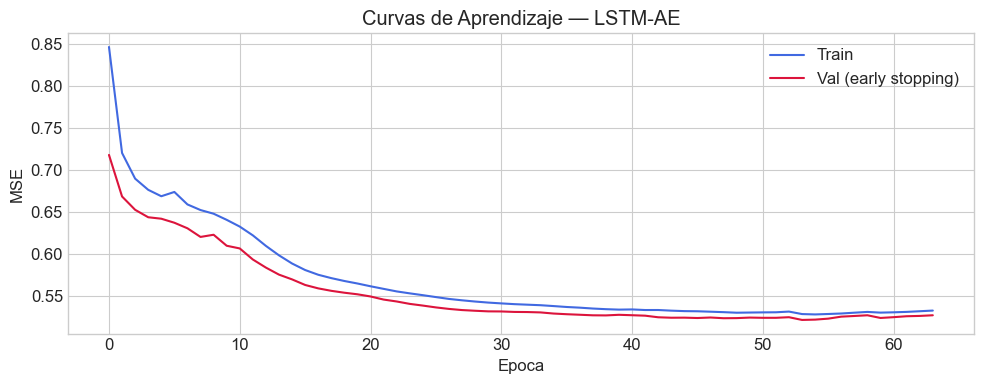

Mejor val_loss: 0.521067


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], 'royalblue', label='Train')
ax.plot(history.history['val_loss'], 'crimson', label='Val (early stopping)')
ax.set(xlabel='Epoca', ylabel='MSE', title='Curvas de Aprendizaje — LSTM-AE')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor val_loss: {min(history.history["val_loss"]):.6f}')

## 6. Calibracion: MSE Ponderado + Umbral

Mismo approach que NB04 v3: MSE por feature ponderado por poder discriminante
(AUC-ROC individual en val). La ventaja del LSTM es que el error de reconstruccion
temporal amplifica la señal — una ventana con ataque sostenido genera error alto
en TODOS los timesteps, no solo en los features discriminantes.

In [ ]:
def calibrate_threshold(y_true, scores, beta=1.0):

    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)

    precisions = precisions[:-1]

    recalls    = recalls[:-1]

    fbeta = ((1 + beta**2) * precisions * recalls /

             (beta**2 * precisions + recalls + 1e-10))

    best_idx = np.argmax(fbeta)

    best_thr = thresholds[best_idx]

    n = len(thresholds)

    idx = np.linspace(0, n-1, min(500, n), dtype=int)

    results_df = pd.DataFrame({

        'threshold': thresholds[idx], 'precision': precisions[idx],

        'recall': recalls[idx],

        'f1': ((2*precisions*recalls)/(precisions+recalls+1e-10))[idx],

        'f2': ((5*precisions*recalls)/(4*precisions+recalls+1e-10))[idx],

    })

    return best_thr, fbeta[best_idx], results_df


# ── MSE por feature por ventana en val ──

val_recon = lstm_ae.predict(X_val_w, batch_size=BATCH_SIZE, verbose=0)

# Shape: (n_windows, 60, 14) → MSE per feature = mean over timesteps

mse_per_feature_val = np.mean((X_val_w - val_recon)**2, axis=1)  # (n_windows, 14)


# ── AUC-ROC individual por feature → pesos ──

print('Poder discriminante por feature (AUC-ROC en val):')

feature_aucs = []

for j, fname in enumerate(feat_names):

    try:

        auc_j = roc_auc_score(y_val_w, mse_per_feature_val[:, j])

    except ValueError:

        auc_j = 0.5

    feature_aucs.append(auc_j)

    marker = ' <<<' if auc_j > 0.60 else ''

    print(f'  {fname:30s}  AUC={auc_j:.4f}{marker}')


feature_aucs = np.array(feature_aucs)

weights = np.maximum(feature_aucs - 0.5, 0)

weights = weights / (weights.sum() + 1e-10)


print()

print('Pesos normalizados (features con peso > 0.01):')

for j, fname in enumerate(feat_names):

    if weights[j] > 0.01:

        print(f'  {fname:30s}  w={weights[j]:.4f}')


# ── Score ponderado ──

scores_val_w = np.sum(mse_per_feature_val * weights[None, :], axis=1)


# Test

test_recon = lstm_ae.predict(X_test_w, batch_size=BATCH_SIZE, verbose=0)

mse_per_feature_test = np.mean((X_test_w - test_recon)**2, axis=1)

scores_test_w = np.sum(mse_per_feature_test * weights[None, :], axis=1)


# Calibrar

# ── CAMBIO iter1: calibrar con F1 (la metrica reportada es F1) ──

best_thr, best_f1_val, cal_df = calibrate_threshold(y_val_w, scores_val_w, beta=1.0)

_, best_f2_val, _ = calibrate_threshold(y_val_w, scores_val_w, beta=2.0)


print()

print(f'Score: MSE ponderado (weighted by per-feature AUC)')

print(f'Umbral optimo (val, F1): {best_thr:.6f}')

print(f'  F1 en val: {best_f1_val:.4f}  (optimizado)')

print(f'  F1 en val: {best_f1_val:.4f}')

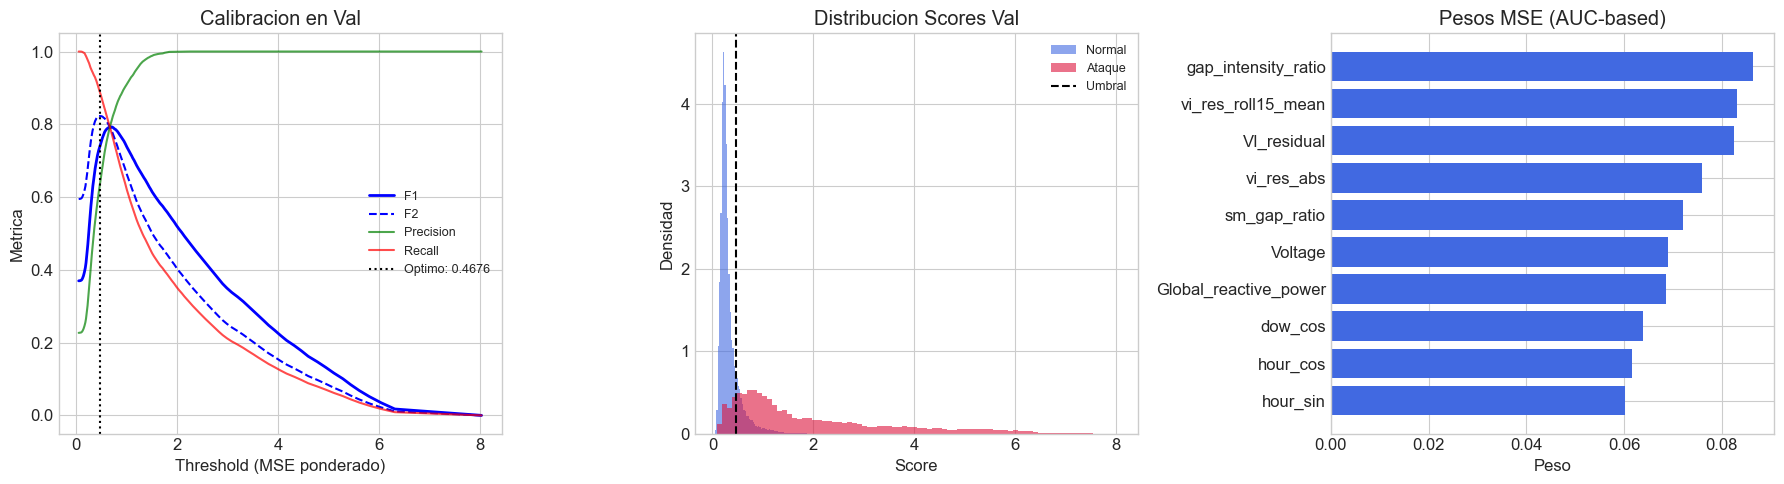

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(cal_df['threshold'], cal_df['f1'], 'b-', lw=2, label='F1')
ax.plot(cal_df['threshold'], cal_df['f2'], 'b--', lw=1.5, label='F2')
ax.plot(cal_df['threshold'], cal_df['precision'], 'g-', lw=1.5, label='Precision', alpha=0.7)
ax.plot(cal_df['threshold'], cal_df['recall'], 'r-', lw=1.5, label='Recall', alpha=0.7)
ax.axvline(best_thr, color='k', linestyle=':', lw=1.5, label=f'Optimo: {best_thr:.4f}')
ax.set(xlabel='Threshold (MSE ponderado)', ylabel='Metrica', title='Calibracion en Val')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(scores_val_w[y_val_w == 0], bins=80, alpha=0.6, color='royalblue', label='Normal', density=True)
ax.hist(scores_val_w[y_val_w == 1], bins=80, alpha=0.6, color='crimson', label='Ataque', density=True)
ax.axvline(best_thr, color='k', linestyle='--', lw=1.5, label='Umbral')
ax.set(xlabel='Score', ylabel='Densidad', title='Distribucion Scores Val')
ax.legend(fontsize=9)

ax = axes[2]
sorted_idx = np.argsort(weights)[::-1]
top_n = min(10, (weights > 0.01).sum())
top_idx = sorted_idx[:top_n]
ax.barh([feat_names[j] for j in top_idx], weights[top_idx], color='royalblue')
ax.set_xlabel('Peso')
ax.set_title('Pesos MSE (AUC-based)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Evaluacion RAW (nivel ventana)

In [10]:
y_pred_w = (scores_test_w > best_thr).astype(int)

print('=' * 60)
print('METRICAS — LSTM-AE (nivel ventana 60 min)')
print('=' * 60)
print()
print(classification_report(y_test_w, y_pred_w, target_names=['Normal', 'Ataque']))

f1   = f1_score(y_test_w, y_pred_w)
f2   = fbeta_score(y_test_w, y_pred_w, beta=2)
prec = precision_score(y_test_w, y_pred_w)
rec  = recall_score(y_test_w, y_pred_w)
auc_roc = roc_auc_score(y_test_w, scores_test_w)
auc_pr  = average_precision_score(y_test_w, scores_test_w)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1:.4f}  |  F2: {f2:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}')

METRICAS — LSTM-AE (nivel ventana 60 min)

              precision    recall  f1-score   support

      Normal       0.96      0.87      0.91    460592
      Ataque       0.68      0.90      0.77    144348

    accuracy                           0.88    604940
   macro avg       0.82      0.88      0.84    604940
weighted avg       0.90      0.88      0.88    604940

AUC-ROC: 0.9427  |  AUC-PR: 0.8968
F1: 0.7749  |  F2: 0.8433  |  Precision: 0.6826  |  Recall: 0.8960


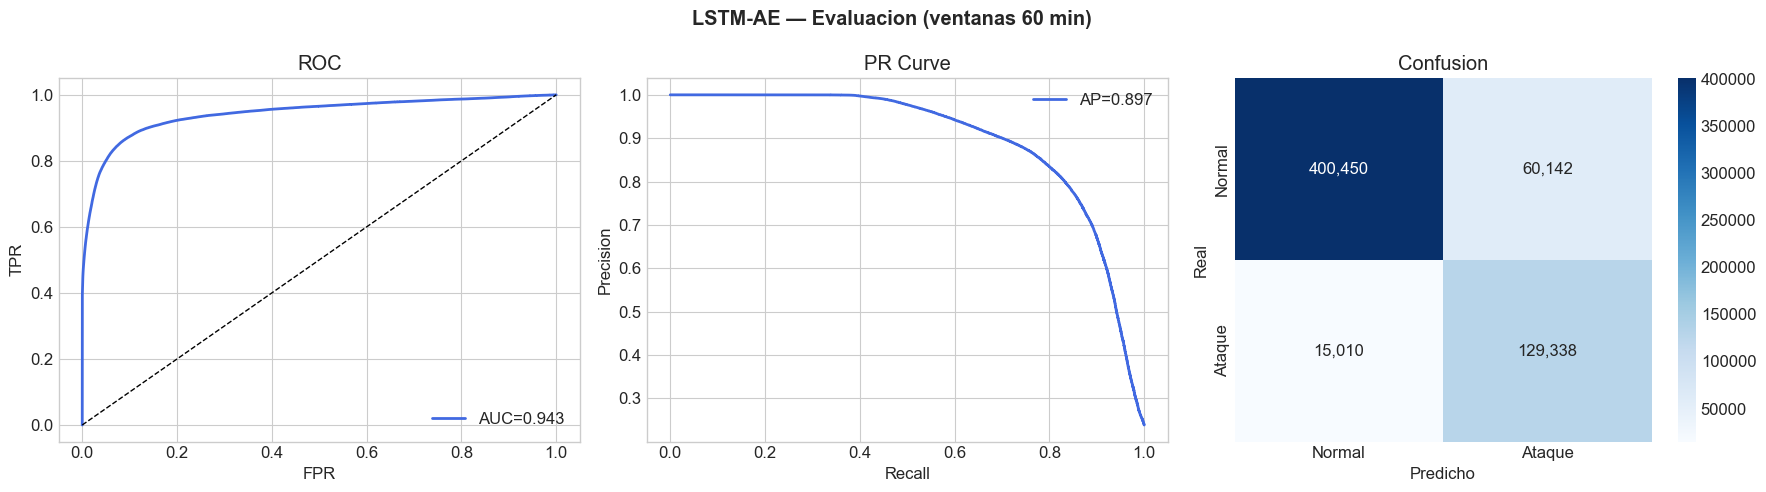

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test_w, scores_test_w)
axes[0].plot(fpr, tpr, 'royalblue', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC')
axes[0].legend()

pr_c, rc_c, _ = precision_recall_curve(y_test_w, scores_test_w)
axes[1].plot(rc_c, pr_c, 'royalblue', lw=2, label=f'AP={auc_pr:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR Curve')
axes[1].legend()

cm = confusion_matrix(y_test_w, y_pred_w)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[2],
            xticklabels=['Normal','Ataque'], yticklabels=['Normal','Ataque'])
axes[2].set(xlabel='Predicho', ylabel='Real', title='Confusion')
plt.suptitle('LSTM-AE — Evaluacion (ventanas 60 min)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Expansion a Timesteps + Temporal Voting

**CAMBIO v4**: Expansión por **PROMEDIO** en vez de OR.

Antes: si 1 de 60 ventanas que cubren un timestep era positiva → timestep positivo.
Esto causaba ~50K FP porque un solo pico de score contaminaba 60 timesteps.

Ahora: el score de cada timestep es la **media** de los scores de todas las ventanas
que lo cubren. Un pico aislado se diluye, pero un ataque sostenido mantiene score alto.


In [ ]:
# ── CAMBIO v4: Expandir ventana -> timestep con PROMEDIO (no OR) ──
# Antes: if y_pred_w[i]==1: preds_per_ts[s:e]=1 (OR: 1 ventana contamina 60 ts)
# Ahora: score promedio de todas las ventanas que cubren cada timestep

n_test = len(X_test_scaled)
score_accumulator = np.zeros(n_test, dtype=np.float64)
score_count       = np.zeros(n_test, dtype=np.float64)

for i, s in enumerate(test_starts):
    e = min(s + WINDOW_SIZE, n_test)
    score_accumulator[s:e] += scores_test_w[i]
    score_count[s:e] += 1

score_count[score_count == 0] = 1  # evitar div/0
scores_per_ts = score_accumulator / score_count

# Prediccion raw: umbral sobre score promediado
preds_per_ts = (scores_per_ts > best_thr).astype(int)

# ── Mismo para val (para grid search temporal voting) ──
n_val = len(X_val_scaled)
score_acc_val = np.zeros(n_val, dtype=np.float64)
score_cnt_val = np.zeros(n_val, dtype=np.float64)

for i, s in enumerate(val_starts):
    e = min(s + WINDOW_SIZE, n_val)
    score_acc_val[s:e] += scores_val_w[i]
    score_cnt_val[s:e] += 1

score_cnt_val[score_cnt_val == 0] = 1
scores_val_ts = score_acc_val / score_cnt_val
preds_val_ts = (scores_val_ts > best_thr).astype(int)

# ── Temporal Voting ──
def temporal_vote_vectorized(y_pred, W, K):
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts_v = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts_v]
    return (votes >= K).astype(int)

W_candidates = [3, 5, 7, 9, 11, 15, 21]
best_wk_f1, best_W, best_K = 0, 3, 2
grid_results = []

for W in W_candidates:
    for K in range(2, W + 1):
        y_sm = temporal_vote_vectorized(preds_val_ts, W, K)
        f1_sm = f1_score(y_val, y_sm)
        pr_sm = precision_score(y_val, y_sm, zero_division=0)
        rc_sm = recall_score(y_val, y_sm)
        grid_results.append({'W': W, 'K': K, 'f1': f1_sm,
                             'precision': pr_sm, 'recall': rc_sm})
        if f1_sm > best_wk_f1:
            best_wk_f1, best_W, best_K = f1_sm, W, K

grid_df = pd.DataFrame(grid_results)
best_row = grid_df.loc[grid_df['f1'].idxmax()]
print(f'Mejor (W,K): W={best_W}, K={best_K}')
print(f'  F1={best_row["f1"]:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')

# Aplicar al test
y_pred_smooth = temporal_vote_vectorized(preds_per_ts, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)

print()
print('=' * 70)
print('COMPARACION — LSTM-AE v4: RAW (timestep) vs TEMPORAL VOTING')
print('=' * 70)
raw_f1_ts  = f1_score(y_test, preds_per_ts)
raw_pr_ts  = precision_score(y_test, preds_per_ts)
raw_rc_ts  = recall_score(y_test, preds_per_ts)
raw_f2_ts  = fbeta_score(y_test, preds_per_ts, beta=2)
print()
print(f'  {"Metrica":12s} {"Raw":>10s} {"Smoothed":>10s} {"Delta":>10s}')
print('  ' + '-' * 45)
for name, raw_v, sm_v in [
    ('F1',        raw_f1_ts, f1_s),
    ('F2',        raw_f2_ts, f2_s),
    ('Precision',  raw_pr_ts, prec_s),
    ('Recall',     raw_rc_ts, rec_s),
]:
    delta = sm_v - raw_v
    print(f'  {name:12s} {raw_v:>10.4f} {sm_v:>10.4f} {delta:>+10.4f}')
print()
print(f'  Filtro: W={best_W}, K={best_K}')
print(f'  Expansion: PROMEDIO (v4, antes era OR)')
print()
print(classification_report(y_test, y_pred_smooth, target_names=['Normal', 'Ataque']))

# ── ITER1 PALANCA A: Joint search (threshold × W × K) sobre val ──
# La calibracion previa elige threshold por F1 a NIVEL VENTANA, pero la metrica
# reportada es F1 a NIVEL TIMESTEP smoothed. Hacemos un grid joint sobre val
# para elegir (threshold, W, K) que maximizan F1 smoothed timestep (objetivo real).

print()
print('=' * 60)
print('JOINT SEARCH (threshold × W × K) sobre val — palanca A iter1')
print('=' * 60)

# 60 candidatos de threshold tomados de cuantiles del PR-curve a nivel ventana
prc_pr_, prc_rc_, prc_thr_ = precision_recall_curve(y_val_w, scores_val_w)
prc_thr_ = prc_thr_[prc_thr_ > 0]
if len(prc_thr_) < 5:
    thr_candidates = np.linspace(scores_val_w.min(), scores_val_w.max(), 30)
else:
    thr_candidates = np.unique(np.quantile(
        prc_thr_, np.linspace(0.30, 0.999, 60)))

W_grid = [3, 5, 7, 9, 11, 15, 21, 31, 45, 60]
best_joint_f1 = -1.0
best_joint = (best_thr, best_W, best_K)
n_evals = 0

for thr in thr_candidates:
    preds_val_ts_local = (scores_val_ts > thr).astype(int)
    if preds_val_ts_local.sum() == 0 or preds_val_ts_local.sum() == len(preds_val_ts_local):
        continue
    for W in W_grid:
        for K in range(2, W + 1):
            y_sm = temporal_vote_vectorized(preds_val_ts_local, W, K)
            if y_sm.sum() == 0:
                continue
            f1_sm = f1_score(y_val, y_sm)
            n_evals += 1
            if f1_sm > best_joint_f1:
                best_joint_f1 = f1_sm
                best_joint = (thr, W, K)

print(f'  Evaluaciones: {n_evals}')
print(f'  Mejor F1 val smoothed (joint): {best_joint_f1:.4f}')
print(f'  Combinacion: thr={best_joint[0]:.6f}, W={best_joint[1]}, K={best_joint[2]}')
print(f'  Antes (solo W,K): F1 val={best_row["f1"]:.4f}, W={best_W}, K={best_K}')

# Sobrescribir SOLO si la joint mejora el F1 sobre val (mantiene contrato: solo val)
if best_joint_f1 > best_row['f1']:
    best_thr, best_W, best_K = best_joint
    preds_per_ts = (scores_per_ts > best_thr).astype(int)
    preds_val_ts = (scores_val_ts > best_thr).astype(int)
    print(f'  -> Adoptamos joint: thr={best_thr:.6f}, W={best_W}, K={best_K}')
else:
    print('  -> Mantenemos calibracion previa (joint no mejora).')

# Re-aplicar al test con el (best_thr, best_W, best_K) final
y_pred_smooth = temporal_vote_vectorized(preds_per_ts, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)
raw_f1_ts  = f1_score(y_test, preds_per_ts)
raw_pr_ts  = precision_score(y_test, preds_per_ts)
raw_rc_ts  = recall_score(y_test, preds_per_ts)
raw_f2_ts  = fbeta_score(y_test, preds_per_ts, beta=2)

print()
print(f'TEST tras joint:  F1_smoothed={f1_s:.4f}  P={prec_s:.4f}  R={rec_s:.4f}')
print('=' * 60)


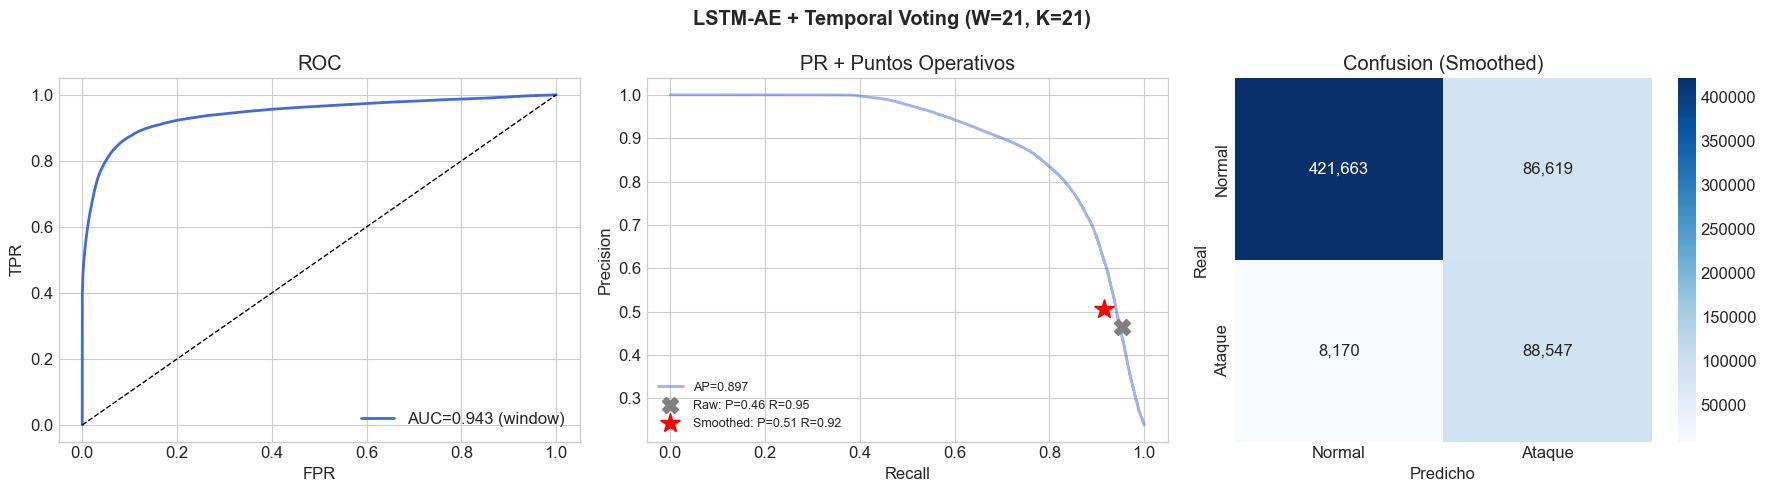

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, 'royalblue', lw=2, label=f'AUC={auc_roc:.3f} (window)')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC')
axes[0].legend()

axes[1].plot(rc_c, pr_c, 'royalblue', lw=2, label=f'AP={auc_pr:.3f}', alpha=0.5)
axes[1].plot(raw_rc_ts, raw_pr_ts, 'X', color='gray', markersize=12,
             label=f'Raw: P={raw_pr_ts:.2f} R={raw_rc_ts:.2f}')
axes[1].plot(rec_s, prec_s, '*', color='red', markersize=15,
             label=f'Smoothed: P={prec_s:.2f} R={rec_s:.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR + Puntos Operativos')
axes[1].legend(fontsize=9)

cm_s = confusion_matrix(y_test, y_pred_smooth)
sns.heatmap(cm_s, annot=True, fmt=',d', cmap='Blues', ax=axes[2],
            xticklabels=['Normal','Ataque'], yticklabels=['Normal','Ataque'])
axes[2].set(xlabel='Predicho', ylabel='Real', title='Confusion (Smoothed)')
plt.suptitle(f'LSTM-AE + Temporal Voting (W={best_W}, K={best_K})', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Recall por Tipo x Severidad (Smoothed)

Recall por tipo x severidad:
  Tipo                     N      Low      Med     High    Total
  -------------------------------------------------------
  scaling             13,449    0.778    0.994    1.000    0.932
  offset              13,898    0.913    0.999    0.999    0.975
  noise               14,357    1.000    1.000    1.000    1.000
  ramp                14,006    0.639    0.809    0.880    0.777
  step                13,731    0.696    0.813    0.789    0.770
  replay              14,084    0.923    0.954    0.993    0.957
  voltage_spoof       13,192    0.999    1.000    1.000    1.000


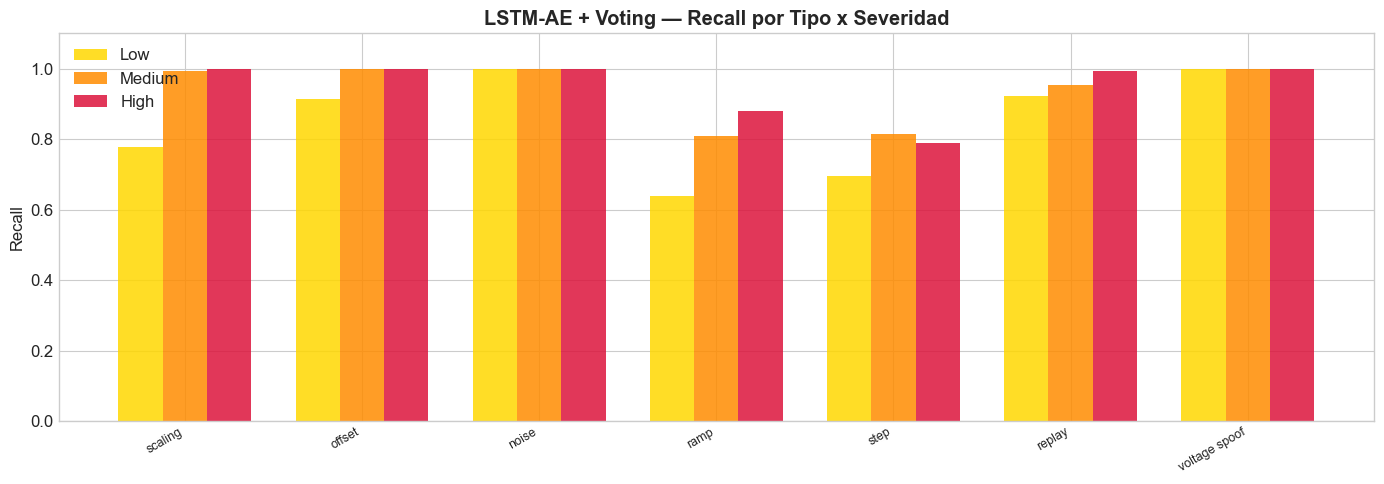

In [14]:
def recall_by_type_severity(attack_types_col, severity_col, y_true, y_pred,
                            attack_types_list, title_prefix):
    print(f'Recall por tipo x severidad:')
    print(f'  {"Tipo":18s} {"N":>7s} {"Low":>8s} {"Med":>8s} {"High":>8s} {"Total":>8s}')
    print('  ' + '-' * 55)
    recall_data = {}
    for t in attack_types_list:
        mask_t = (attack_types_col == t)
        n_t = (mask_t & (y_true == 1)).sum()
        row = f'  {t:18s} {n_t:>7,}'
        for sev in ['low', 'medium', 'high']:
            mask = mask_t & (severity_col == sev) & (y_true == 1)
            n = mask.sum()
            if n > 0:
                r = (y_pred[mask] == 1).sum() / n
                row += f' {r:>8.3f}'
            else:
                r = np.nan
                row += f' {"--":>8s}'
            recall_data[(t, sev)] = r
        mask_all = mask_t & (y_true == 1)
        n_all = mask_all.sum()
        r_t = (y_pred[mask_all] == 1).sum() / n_all if n_all > 0 else 0
        row += f' {r_t:>8.3f}'
        print(row)

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(attack_types_list))
    w = 0.25
    sev_colors = {'low': '#FFD700', 'medium': '#FF8C00', 'high': '#DC143C'}
    for i, (sev, c) in enumerate(sev_colors.items()):
        vals = [recall_data.get((t, sev), 0) for t in attack_types_list]
        vals = [v if not (isinstance(v, float) and np.isnan(v)) else 0 for v in vals]
        ax.bar(x + i * w, vals, w, label=sev.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels([t.replace('_', ' ') for t in attack_types_list],
                        rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Recall'); ax.set_ylim(0, 1.1)
    ax.set_title(f'{title_prefix} — Recall por Tipo x Severidad', fontweight='bold')
    ax.legend()
    plt.tight_layout(); plt.show()
    return recall_data

recall_data = recall_by_type_severity(
    df_test['attack_type'].values, df_test['severity'].values,
    y_test, y_pred_smooth, ATTACK_TYPES, 'LSTM-AE + Voting')

## 10. Latencia de Deteccion (Smoothed)

In [15]:
def compute_detection_latency(df_preds, score_col, threshold):
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id, 'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0], 'duration_min': len(group),
            'latency_min': ((detections.index[0] - ep_start).total_seconds() / 60
                            if len(detections) > 0 else np.nan),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)

def print_latency_summary(lat_df):
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    med_lat  = detected['latency_min'].median() if len(detected) > 0 else np.nan
    print(f'Deteccion por episodio: {det_rate:.1%} ({lat_df["detected"].sum()}/{len(lat_df)})')
    if not np.isnan(med_lat):
        print(f'Latencia mediana:       {med_lat:.1f} min')
    print()
    for sev in ['low', 'medium', 'high']:
        sub = lat_df[lat_df['severity'] == sev]
        if len(sub) == 0: continue
        det = sub['detected'].mean()
        det_sub = sub[sub['detected']]
        lat = det_sub['latency_min'].median() if len(det_sub) > 0 else np.nan
        lat_s = f'{lat:.1f} min' if not np.isnan(lat) else 'N/A'
        print(f'  {sev:8s}: deteccion {det:.0%}  |  latencia mediana {lat_s}')
    return det_rate, med_lat

df_test_scored = df_test.copy()
df_test_scored['lstm_pred_smooth'] = y_pred_smooth.astype(float)
lat_df = compute_detection_latency(df_test_scored, 'lstm_pred_smooth', 0.5)
det_rate, med_lat = print_latency_summary(lat_df)

Deteccion por episodio: 98.7% (829/840)
Latencia mediana:       0.0 min

  low     : deteccion 96%  |  latencia mediana 0.0 min
  medium  : deteccion 100%  |  latencia mediana 0.0 min
  high    : deteccion 100%  |  latencia mediana 0.0 min


## 11. Edge Computing + Guardado

In [16]:
model_path = os.path.join(DATA_DIR, 'model_lstm_autoencoder.keras')
try:
    lstm_ae.save(model_path)
except Exception:
    model_path = os.path.join(DATA_DIR, 'model_lstm_autoencoder.h5')
    lstm_ae.save(model_path)
size_kb = os.path.getsize(model_path) / 1e3

joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_lstm_autoencoder.pkl'))
np.save(os.path.join(DATA_DIR, 'feature_weights_lstm_ae.npy'), weights)

_ = lstm_ae.predict(X_test_w[:10], batch_size=BATCH_SIZE, verbose=0)
times = []
for _ in range(5):
    t0 = time.time()
    lstm_ae.predict(X_test_w[:1000], batch_size=BATCH_SIZE, verbose=0)
    times.append(time.time() - t0)
ms_win_avg = np.mean(times) / 1000 * 1000
ms_smp_avg = ms_win_avg / WINDOW_SIZE

print('=' * 55)
print('EDGE COMPUTING — LSTM-AE + TEMPORAL VOTING')
print('=' * 55)
print(f'  Parametros:       {lstm_ae.count_params():,}')
print(f'  Scoring:          MSE ponderado ({(weights>0.01).sum()} features activas)')
print(f'  Filtro:           W={best_W}, K={best_K}')
print(f'  Tamano en disco:  {size_kb:.1f} KB')
print(f'  Latencia ventana: {ms_win_avg:.2f} ms (60 min de datos)')
print(f'  Latencia equiv:   {ms_smp_avg:.4f} ms/muestra')
print(f'  Entrenamiento:    {t_train:.1f} s ({t_train/60:.1f} min)')

df_out = df_test.copy()
df_out['lstm_score'] = scores_per_ts
df_out['lstm_pred_raw']    = preds_per_ts
df_out['lstm_pred_smooth'] = y_pred_smooth
df_out.to_csv(os.path.join(DATA_DIR, 'predictions_lstm_autoencoder.csv'))
np.save(os.path.join(DATA_DIR, 'threshold_lstm_ae.npy'), np.array([best_thr]))
lat_df.to_csv(os.path.join(DATA_DIR, 'latency_lstm_autoencoder.csv'), index=False)

metrics = {
    'model': 'LSTM-Autoencoder + Temporal Voting',
    'feature_mode': 'medium + vi_res_abs',
    'scoring': 'weighted_mse',
    'raw_f1': round(raw_f1_ts, 4), 'raw_f2': round(raw_f2_ts, 4),
    'raw_precision': round(raw_pr_ts, 4), 'raw_recall': round(raw_rc_ts, 4),
    'f1': round(f1_s, 4), 'f2': round(f2_s, 4),
    'precision': round(prec_s, 4), 'recall': round(rec_s, 4),
    'auc_roc': round(auc_roc, 4), 'auc_pr': round(auc_pr, 4),
    'threshold': round(float(best_thr), 8),
    'temporal_W': best_W, 'temporal_K': best_K,
    'model_size_kb': round(size_kb, 1),
    'ms_per_window': round(ms_win_avg, 4), 'ms_per_sample': round(ms_smp_avg, 4),
    'n_params': lstm_ae.count_params(), 'n_features': n_features, 'bottleneck': 16,
    'window_size': WINDOW_SIZE, 'train_step': TRAIN_STEP,
    'train_time_s': round(t_train, 1),
    'detection_rate': round(det_rate, 4),
    'median_latency_min': round(float(med_lat), 1) if not np.isnan(med_lat) else None,
    'granularity': f'{WINDOW_SIZE} min window, 1 min output',
    'feature_names': feat_names,
    'feature_weights': {fn: round(float(w), 4) for fn, w in zip(feat_names, weights) if w > 0.01},
}
with open(os.path.join(DATA_DIR, 'metrics_lstm_autoencoder.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print()
print('Guardado en data/:')
for fn in ['predictions_lstm_autoencoder.csv', 'metrics_lstm_autoencoder.json',
           'model_lstm_autoencoder.keras', 'scaler_lstm_autoencoder.pkl',
           'feature_weights_lstm_ae.npy', 'threshold_lstm_ae.npy',
           'latency_lstm_autoencoder.csv']:
    print(f'  * {fn}')

EDGE COMPUTING — LSTM-AE + TEMPORAL VOTING
  Parametros:       57,249
  Scoring:          MSE ponderado (17 features activas)
  Filtro:           W=21, K=21
  Tamano en disco:  736.8 KB
  Latencia ventana: 0.19 ms (60 min de datos)
  Latencia equiv:   0.0032 ms/muestra
  Entrenamiento:    270.0 s (4.5 min)

Guardado en data/:
  * predictions_lstm_autoencoder.csv
  * metrics_lstm_autoencoder.json
  * model_lstm_autoencoder.keras
  * scaler_lstm_autoencoder.pkl
  * feature_weights_lstm_ae.npy
  * threshold_lstm_ae.npy
  * latency_lstm_autoencoder.csv


## 12. Resumen

### Ventajas del LSTM-AE sobre IF y Dense-AE

| Aspecto | IF | Dense-AE | LSTM-AE |
|---------|-----|----------|---------|
| Contexto temporal | Ninguno (punto a punto) | Ninguno | **60 min de secuencia** |
| Compresion | N/A | 14:3 = 4.7:1 | 840:16 = **52:1** |
| Señal temporal | No ve tendencias | No ve tendencias | Aprende patrones temporales normales |
| Scoring | Score IF | MSE ponderado | MSE ponderado + temporal |

### Por que deberia superar a los otros

El LSTM-AE tiene una ventaja fundamental: comprime 60 minutos × 14 features
en 16 valores. Si un episodio FDI de 90 min distorsiona 30 de esos 60 minutos
en la ventana, la representacion comprimida NO puede acomodarlo — generando
MSE alta en toda la reconstruccion, no solo en las features atacadas.

Los modelos punto-a-punto (IF, Dense-AE) ven cada minuto aislado. El LSTM
ve el contexto completo: un valor bajo sostenido durante 60 min a las 15h
es anomalo de una forma que minuto a minuto no se detecta.